<a href="https://colab.research.google.com/github/AlejandroRomero121/Herramientas/blob/main/TRABAJO_HERRAMIENTAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

Esta celda importa las librerías necesarias para el análisis de datos y la visualización:

pandas (como pd): Es una librería fundamental para la manipulación y análisis de datos en Python. Se utiliza para trabajar con DataFrames, que son estructuras de datos tabulares.
matplotlib.pyplot (como plt): Es una librería para crear visualizaciones estáticas, animadas e interactivas en Python. Se usa para generar gráficos como los diagramas de caja y los histogramas.
seaborn (como sns): Es una librería de visualización de datos basada en Matplotlib que proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.

In [ ]:
df = pd.read_csv('Sales Data.csv')
df

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0.0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7.0
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18.0
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15.0
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12.0
...,...,...,...,...,...,...,...,...,...,...,...
95608,13296,206737,Wired Headphones,1,11.99,2019-05-08 13:21:00,"750 Park St, San Francisco, CA 94016",5,11.99,San Francisco,13.0
95609,13297,206738,27in FHD Monitor,1,149.99,2019-05-09 10:35:00,"879 Ridge St, Atlanta, GA 30301",5,149.99,Atlanta,10.0
95610,13298,206739,Lightning Charging Cable,2,14.95,2019-05-24 11:26:00,"926 8th St, Los Angeles, CA 90001",5,29.90,Los Angeles,11.0
95611,13299,206740,Apple Airpods Headphones,1,150.00,2019-05-03 14:50:00,"753 5th St, New York City, NY 10001",5,150.00,New York City,14.0


En esta celda:

Se carga un archivo CSV llamado Sales Data.csv en un DataFrame de pandas y se le asigna el nombre df.
Luego, se imprime el DataFrame df, lo que muestra las primeras y últimas filas, el nombre de las columnas, la cantidad de filas y columnas, y los tipos de datos de cada columna. Esto ayuda a tener una vista rápida de la estructura y el contenido de los datos.

In [ ]:
X = df[['Quantity Ordered', 'Price Each', 'Month', 'Hour']]
y = df['Sales']

print("Primeras 5 filas de las características (X):")
print(X.head())
print("\nPrimeras 5 filas de la variable objetivo (y):")
print(y.head())

Primeras 5 filas de las características (X):
   Quantity Ordered  Price Each  Month  Hour
0                 1     1700.00     12   0.0
1                 1      600.00     12   7.0
2                 1       11.95     12  18.0
3                 1      149.99     12  15.0
4                 1       11.95     12  12.0

Primeras 5 filas de la variable objetivo (y):
0    1700.00
1     600.00
2      11.95
3     149.99
4      11.95
Name: Sales, dtype: float64


## Explicación de la Definición de Variables X e Y

En esta etapa, estamos preparando nuestro conjunto de datos para un modelo de Machine Learning. El objetivo es predecir la variable `Sales` (ventas) utilizando otras características de nuestro DataFrame `df`.

### **X (Variables Predictoras / Características)**

`X = df[['Quantity Ordered', 'Price Each', 'Month', 'Hour']]`

Aquí, se selecciona un subconjunto de columnas del DataFrame `df` para formar las **características** o **variables predictoras** (`X`). Estas son las variables de entrada que el modelo utilizará para hacer predicciones. En este caso, son:

*   **'Quantity Ordered'**: La cantidad de productos pedidos en cada transacción.
*   **'Price Each'**: El precio unitario de cada artículo.
*   **'Month'**: El mes en que se realizó la venta.
*   **'Hour'**: La hora del día en que se realizó la venta.

Estas características se consideran relevantes para influir en el valor de las ventas.

### **Y (Variable Objetivo / Dependiente)**

`y = df['Sales']`

Esta línea define la **variable objetivo** o **dependiente** (`y`). Esta es la variable que queremos que nuestro modelo de Machine Learning prediga. En este escenario, `Sales` representa el total de ventas de cada transacción.


### **¿Por qué dividir en X e Y?**

Esta división es fundamental en Machine Learning:

*   **X** (las características) se usan para entrenar al modelo. El modelo aprende patrones y relaciones dentro de estas características.
*   **Y** (la variable objetivo) es lo que el modelo intenta predecir. Durante el entrenamiento, el modelo ajusta sus parámetros para que sus predicciones de `y` sean lo más cercanas posible a los valores reales de `y` en los datos de entrenamiento.

Los `print` al final (`print(X.head())` y `print(y.head())`) simplemente muestran las primeras 5 filas de cada uno para que puedas verificar que las variables se han seleccionado correctamente.

## Mean Error Absolute

In [ ]:
from sklearn.metrics import mean_absolute_error
#predicted_home_prices = melbourne_model.predict(X) # This line will cause a NameError as melbourne_model is not defined
#mean_absolute_error(y, predicted_home_prices)


In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        # Impute numerical columns with the median
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Column '{col}' (numerical) imputed with median: {median_val}")

    elif df[col].dtype == 'object':
        # Impute categorical columns with 'perdidos'
        if df[col].isnull().any():
            df[col] = df[col].fillna('perdidos')
            print(f"Column '{col}' (categorical) imputed with 'perdidos'")

print("\nMissing values after imputation:")
df.isnull().sum()[df.isnull().sum() > 0]

Column 'City' (categorical) imputed with 'perdidos'
Column 'Hour' (numerical) imputed with median: 15.0

Missing values after imputation:


,0


##Celda 3: Imputación de Valores Faltantes
sta celda se encarga de manejar los valores faltantes (NaN) en el DataFrame df:

Itera sobre cada columna del DataFrame.
Si la columna es numérica (int64 o float64) y tiene valores faltantes, imputa esos valores con la mediana de la columna. La mediana es una medida de tendencia central que es menos sensible a los valores atípicos que la media.
Si la columna es de tipo 'object' (generalmente cadenas de texto o datos categóricos) y tiene valores faltantes, los imputa con la cadena 'perdidos'.
Finalmente, imprime un resumen de los valores faltantes restantes en el DataFrame para confirmar que la imputación se realizó correctamente (esperando que no haya valores faltantes).

In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

duplicates_removed = initial_rows - final_rows

print(f"Se eliminaron {duplicates_removed} filas duplicadas.")

Se eliminaron 0 filas duplicadas.


##Celda 4: Eliminación de Duplicados
Esta celda busca y elimina filas duplicadas del DataFrame df:

Almacena el número inicial de filas en initial_rows.
Utiliza el método drop_duplicates(inplace=True) para eliminar las filas duplicadas directamente en el DataFrame, sin crear una copia nueva.
Almacena el número final de filas en final_rows.
Calcula la cantidad de duplicados eliminados e imprime el resultado. En este caso, el resultado indica que no se eliminaron filas duplicadas, lo que significa que el dataset no contenía filas completamente idénticas.

In [ ]:
df.describe()

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,95613.000000,95613.000000,95613.000000,95613.000000,95613.000000,95613.000000,95613.000000
mean,8673.674887,220337.959127,1.124627,184.980688,6.317352,186.094504,14.403366
std,5810.681014,57411.356056,0.442542,332.507206,3.760016,332.803822,5.413621
min,0.000000,150502.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,4004.000000,173441.000000,1.000000,11.950000,3.000000,11.950000,11.000000
50%,8007.000000,196359.000000,1.000000,14.950000,5.000000,14.950000,15.000000
75%,12009.000000,296703.000000,1.000000,150.000000,12.000000,150.000000,19.000000
max,25116.000000,319670.000000,8.000000,1700.000000,12.000000,3400.000000,23.000000


##Celda 5: Descripción Estadística
Esta celda genera un resumen estadístico de las columnas numéricas del DataFrame df:

Muestra estadísticas descriptivas como el conteo de valores no nulos, la media, la desviación estándar, el valor mínimo, los cuartiles (25%, 50% -mediana-, 75%) y el valor máximo para cada columna numérica. Esto es útil para comprender la distribución y las características clave de los datos.

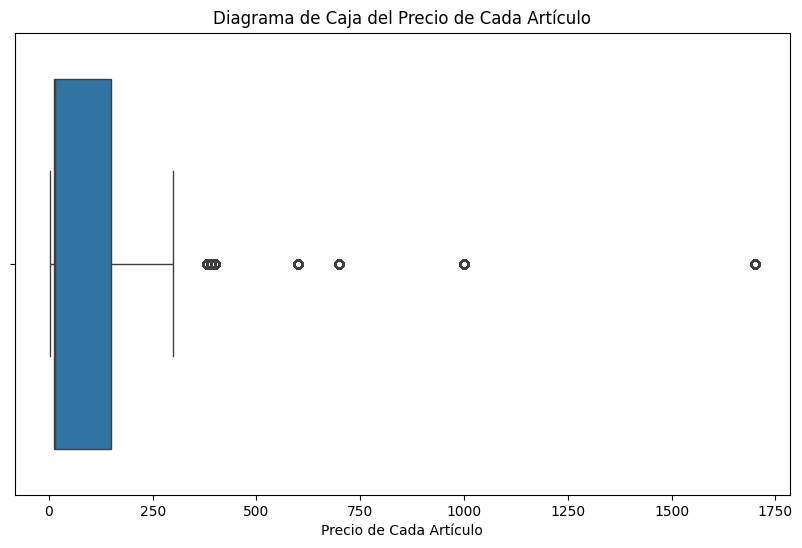


--- Explicación del Diagrama de Caja y Cuartiles ---
Un diagrama de caja (box plot) es una forma estandarizada de mostrar la distribución de datos numéricos a través de sus cuartiles.

Las partes principales son:
1. **Línea central (Mediana o Cuartil 2):** Es la línea que divide la caja en dos. Representa el 50% de los datos, es decir, el punto medio de la distribución.
2. **Caja:** Los bordes superior e inferior de la caja representan el 25% superior (Cuartil 3) y el 25% inferior (Cuartil 1) de los datos, respectivamente.
   - **Cuartil 1 (Q1):** Es el valor por debajo del cual se encuentra el 25% de los datos. También conocido como el percentil 25.
   - **Cuartil 3 (Q3):** Es el valor por debajo del cual se encuentra el 75% de los datos. También conocido como el percentil 75.
3. **Bigotes (Whiskers):** Las líneas que se extienden desde la caja se llaman bigotes. Generalmente, se extienden hasta el último dato que no es un valor atípico.
4. **Puntos (Outliers):** Los puntos individua

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price Each'])
plt.title('Diagrama de Caja del Precio de Cada Artículo')
plt.xlabel('Precio de Cada Artículo')
plt.show()

print("\n--- Explicación del Diagrama de Caja y Cuartiles ---")
print("Un diagrama de caja (box plot) es una forma estandarizada de mostrar la distribución de datos numéricos a través de sus cuartiles.")
print("\nLas partes principales son:")
print("1. **Línea central (Mediana o Cuartil 2):** Es la línea que divide la caja en dos. Representa el 50% de los datos, es decir, el punto medio de la distribución.")
print("2. **Caja:** Los bordes superior e inferior de la caja representan el 25% superior (Cuartil 3) y el 25% inferior (Cuartil 1) de los datos, respectivamente.")
print("   - **Cuartil 1 (Q1):** Es el valor por debajo del cual se encuentra el 25% de los datos. También conocido como el percentil 25.")
print("   - **Cuartil 3 (Q3):** Es el valor por debajo del cual se encuentra el 75% de los datos. También conocido como el percentil 75.")
print("3. **Bigotes (Whiskers):** Las líneas que se extienden desde la caja se llaman bigotes. Generalmente, se extienden hasta el último dato que no es un valor atípico.")
print("4. **Puntos (Outliers):** Los puntos individuales más allá de los bigotes son considerados valores atípicos. Estos son valores que se desvían significativamente del resto.")
print("\nEn resumen, el box plot te permite ver rápidamente:")
print(" - Dónde se concentra la mayoría de los datos (la caja).")
print(" - Cuál es el valor medio (la mediana).")
print(" - La dispersión de los datos (el tamaño de la caja y los bigotes).")
print(" - La presencia de valores atípicos.")

##Celda 6: Diagrama de Caja (Box Plot) y Explicación
En esta celda:

Se crea un diagrama de caja (box plot) de la columna 'Price Each' utilizando la librería seaborn.
El diagrama de caja visualiza la distribución de los precios, mostrando la mediana, los cuartiles, el rango intercuartílico y los posibles valores atípicos.
Se añade un título y una etiqueta al eje X.
Después del gráfico, se imprime una explicación detallada de qué es un diagrama de caja, cómo se interpretan sus partes (mediana, caja, bigotes, valores atípicos) y qué información se puede obtener de él.


In [ ]:
Q1 = df['Price Each'].quantile(0.25)
Q3 = df['Price Each'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price Each'] < lower_bound) | (df['Price Each'] > upper_bound)]

num_outliers = len(outliers)
total_data_points = len(df)

print(f"Número de datos fuera de la caja (outliers) en 'Price Each': {num_outliers}")
print(f"Total de datos en la columna 'Price Each': {total_data_points}")
print(f"Porcentaje de outliers: {(num_outliers / total_data_points * 100):.2f}%")

Número de datos fuera de la caja (outliers) en 'Price Each': 19216
Total de datos en la columna 'Price Each': 95613
Porcentaje de outliers: 20.10%


##Celda 7: Detección de Outliers (Valores Atípicos) por IQR
Esta celda calcula y muestra la cantidad de valores atípicos en la columna 'Price Each' utilizando el método del Rango Intercuartílico (IQR):

Calcula el primer cuartil (Q1) y el tercer cuartil (Q3) de la columna 'Price Each'.
Calcula el Rango Intercuartílico (IQR) como la diferencia entre Q3 y Q1.
Define los límites inferior y superior para identificar outliers: lower_bound = Q1 - 1.5 * IQR y upper_bound = Q3 + 1.5 * IQR.
Filtra el DataFrame para encontrar los valores que están por debajo del límite inferior o por encima del límite superior, considerándolos outliers.
Imprime el número total de outliers encontrados y el porcentaje que representan del total de datos.

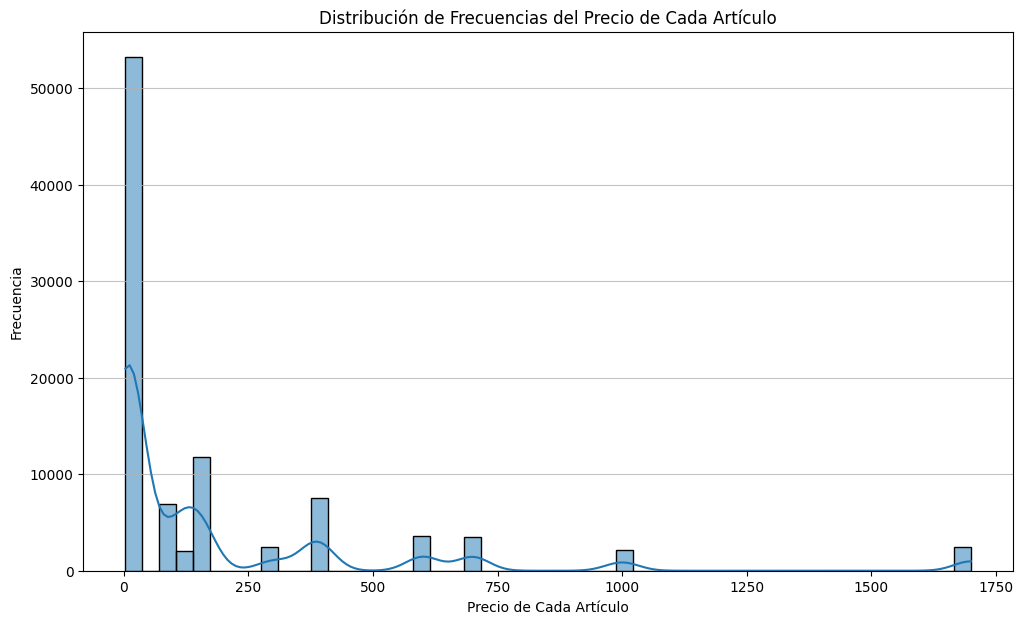


--- Explicación del Histograma ---
Un histograma es una representación gráfica de la distribución de frecuencias de un conjunto de datos numéricos. Cada barra del histograma representa el número de observaciones dentro de un rango específico de valores.

Para detectar casos atípicos (outliers) en un histograma, busca lo siguiente:
1. **Barras aisladas:** Barras muy pequeñas o solitarias que están muy lejos del cuerpo principal de la distribución. Esto indica que hay pocos puntos de datos en ese rango extremo.
2. **Colas largas:** Una distribución que se extiende mucho hacia un lado con barras cada vez más pequeñas. Aunque es una parte natural de algunas distribuciones, colas muy largas pueden indicar valores extremos.

En este histograma, podrás observar la concentración de los precios y si hay algunos valores que aparecen con muy poca frecuencia en los extremos.


In [ ]:

plt.figure(figsize=(12, 7))
sns.histplot(df['Price Each'], bins=50, kde=True)
plt.title('Distribución de Frecuencias del Precio de Cada Artículo')
plt.xlabel('Precio de Cada Artículo')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\n--- Explicación del Histograma ---")
print("Un histograma es una representación gráfica de la distribución de frecuencias de un conjunto de datos numéricos. Cada barra del histograma representa el número de observaciones dentro de un rango específico de valores.")
print("\nPara detectar casos atípicos (outliers) en un histograma, busca lo siguiente:")
print("1. **Barras aisladas:** Barras muy pequeñas o solitarias que están muy lejos del cuerpo principal de la distribución. Esto indica que hay pocos puntos de datos en ese rango extremo.")
print("2. **Colas largas:** Una distribución que se extiende mucho hacia un lado con barras cada vez más pequeñas. Aunque es una parte natural de algunas distribuciones, colas muy largas pueden indicar valores extremos.")
print("\nEn este histograma, podrás observar la concentración de los precios y si hay algunos valores que aparecen con muy poca frecuencia en los extremos.")

##Celda 8: Histograma y Explicación
En esta celda:

Se genera un histograma de la columna 'Price Each' usando seaborn.
El histograma muestra la distribución de frecuencias de los precios, dividiendo los datos en 50 'bins' (barras) y mostrando una estimación de densidad de kernel (kde=True) para suavizar la forma de la distribución.
Se añaden un título, etiquetas para los ejes X e Y, y una cuadrícula para mejorar la legibilidad.
Se incluye una explicación sobre qué es un histograma y cómo se puede utilizar para identificar patrones de distribución y posibles valores atípicos (barras aisladas o colas largas).

In [ ]:
from scipy import stats

# Realizar la prueba de normalidad de D'Agostino-Pearson's K^2
k2, p_value = stats.normaltest(df['Price Each'])

print(f"Estadístico K^2: {k2:.2f}")
print(f"Valor p: {p_value:.3f}")

# Interpretar el resultado
alpha = 0.05
if p_value < alpha:
    print(f"Con un nivel de significancia de {alpha}, rechazamos la hipótesis nula.")
    print("Conclusión: La columna 'Price Each' no pasa la prueba de normalidad (no sigue una distribución normal).")
else:
    print(f"Con un nivel de significancia de {alpha}, no podemos rechazar la hipótesis nula.")
    print("Conclusión: La columna 'Price Each' sí pasa la prueba de normalidad (sigue una distribución normal).")

Estadístico K^2: 56765.28
Valor p: 0.000
Con un nivel de significancia de 0.05, rechazamos la hipótesis nula.
Conclusión: La columna 'Price Each' no pasa la prueba de normalidad (no sigue una distribución normal).


##Celda 9: Prueba de Normalidad de D'Agostino-Pearson's K^2
Esta celda realiza una prueba estadística para determinar si la columna 'Price Each' sigue una distribución normal:

Utiliza la función normaltest de scipy.stats para aplicar la prueba de normalidad de D'Agostino-Pearson's K^2.
La prueba devuelve un estadístico k2 y un p_value.
Se imprime el valor del estadístico K^2 y el valor p.
Finalmente, se interpreta el resultado comparando el p_value con un nivel de significancia alpha (comúnmente 0.05):
Si p_value es menor que alpha, se rechaza la hipótesis nula, lo que significa que los datos no siguen una distribución normal.
Si p_value es mayor o igual que alpha, no se puede rechazar la hipótesis nula, lo que significa que los datos sí podrían seguir una distribución normal.
La salida de esta celda indica que la columna 'Price Each' no pasa la prueba de normalidad, lo que sugiere que sus valores no están distribuidos de forma normal.

In [ ]:
from scipy import stats

# Realizar la prueba de normalidad de D'Agostino-Pearson's K^2 para la columna 'Sales'
k2_sales, p_value_sales = stats.normaltest(df['Sales'])

print(f"Estadístico K^2 para 'Sales': {k2_sales:.2f}")
print(f"Valor p para 'Sales': {p_value_sales:.3f}")

# Interpretar el resultado
alpha = 0.05
if p_value_sales < alpha:
    print(f"Con un nivel de significancia de {alpha}, rechazamos la hipótesis nula.")
    print("Conclusión: La columna 'Sales' no pasa la prueba de normalidad (no sigue una distribución normal).")
else:
    print(f"Con un nivel de significancia de {alpha}, no podemos rechazar la hipótesis nula.")
    print("Conclusión: La columna 'Sales' sí pasa la prueba de normalidad (sigue una distribución normal).")

Estadístico K^2 para 'Sales': 57150.65
Valor p para 'Sales': 0.000
Con un nivel de significancia de 0.05, rechazamos la hipótesis nula.
Conclusión: La columna 'Sales' no pasa la prueba de normalidad (no sigue una distribución normal).


## Prueba de Normalidad para la columna 'Sales'
Esta celda realiza la prueba de normalidad de D'Agostino-Pearson's K^2 para la columna `Sales`. Al igual que con `Price Each`, esta prueba nos ayuda a determinar si los datos de ventas siguen una distribución normal. El resultado nos indicará si podemos asumir normalidad para esta variable o si se necesita aplicar alguna transformación o usar métodos estadísticos no paramétricos.

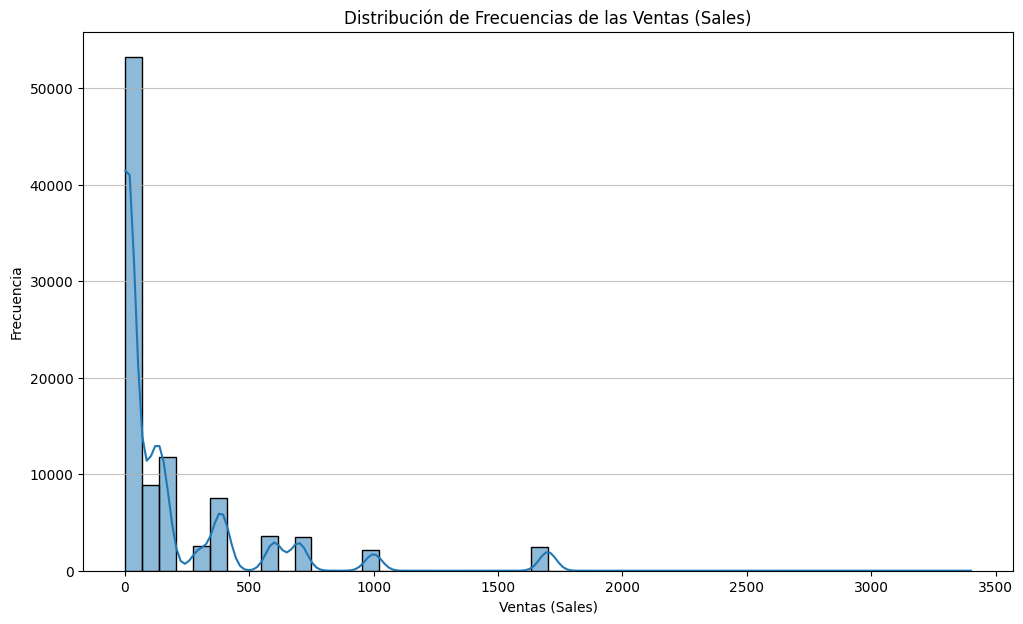

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribución de Frecuencias de las Ventas (Sales)')
plt.xlabel('Ventas (Sales)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Histograma de la Columna 'Sales' y Explicación
Este histograma muestra la distribución de las frecuencias de la columna 'Sales'. Cada barra representa la cantidad de veces que un valor de venta cae dentro de un rango específico.

**Qué observar en el gráfico:**
*   **Forma de la distribución:** Puedes ver si la distribución es simétrica (como una campana, que sería normal) o si está sesgada (inclinada hacia un lado).
*   **Valores más frecuentes:** Las barras más altas indican los rangos de ventas más comunes.
*   **Colas o valores atípicos:** Si hay barras muy pequeñas o valores aislados en los extremos, podrían indicar ventas muy bajas o muy altas que se desvían de la mayoría de los datos, confirmando el resultado de la prueba de normalidad.

# Interpretación estratégica K-MEANS

Perform K-Means clustering on the `product_summary` DataFrame using the `total_sales`, `avg_price_each`, and `total_quantity_ordered` columns. Scale the data using `StandardScaler`, determine the optimal number of clusters (K) using the Elbow Method, apply K-Means with the optimal K, assign cluster labels back to `product_summary`, analyze the characteristics of each cluster, and visualize the clusters.

## Preparación de Datos para Clustering

### Subtask:
Seleccionar las variables numéricas `total_sales`, `avg_price_each` y `total_quantity_ordered` del DataFrame `product_summary` y escalar estas características utilizando `StandardScaler`.


**Razonamiento**:
La subtarea requiere seleccionar columnas numéricas específicas del marco de datos `product_summary` y luego escalarlas usando `StandardScaler`. Primero, seleccionaré las columnas y las almacenaré en un nuevo DataFrame. Luego, importaré `StandardScaler` desde `sklearn.preprocessing` para crear una instancia y aplicarlo a las funciones seleccionadas.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the product_summary DataFrame by aggregating the main df DataFrame
product_summary = df.groupby('Product').agg(
    total_sales=('Sales', 'sum'),
    avg_price_each=('Price Each', 'mean'),
    total_quantity_ordered=('Quantity Ordered', 'sum')
).reset_index()

# 1. Seleccionar las columnas 'total_sales', 'avg_price_each' y 'total_quantity_ordered'
features = product_summary[['total_sales', 'avg_price_each', 'total_quantity_ordered']]

# 2. y 3. Importar StandardScaler y crear una instancia
scaler = StandardScaler()

# 4. Ajustar y transformar los datos
scaled_features = scaler.fit_transform(features)

print("Las primeras 5 filas de las características originales:\n", features.head())
print("\nLas primeras 5 filas de las características escaladas:\n", scaled_features[:5])

Las primeras 5 filas de las características originales:
    total_sales  avg_price_each  total_quantity_ordered
0    228889.19          109.99                    2081
1   1250697.93          389.99                    3207
2    575211.56          149.99                    3835
3   1244847.24          379.99                    3276
4     54543.36            3.84                   14204

Las primeras 5 filas de las características escaladas:
 [[-6.86176117e-01 -6.46044068e-01 -7.40163491e-01]
 [ 3.04713242e-01  2.31644256e-02 -5.07260744e-01]
 [-3.50333275e-01 -5.50442855e-01 -3.77364719e-01]
 [ 2.99039591e-01 -7.35877761e-04 -4.92988729e-01]
 [-8.55246337e-01 -8.99745788e-01  1.76736759e+00]]


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    print(f"K = {k} → Silhouette Score = {score:.4f}")

K = 2 → Silhouette Score = 0.4340
K = 3 → Silhouette Score = 0.5059
K = 4 → Silhouette Score = 0.4775
K = 5 → Silhouette Score = 0.4628
K = 6 → Silhouette Score = 0.4706
K = 7 → Silhouette Score = 0.4758


**Razonamiento**:
El siguiente paso es determinar el número óptimo de grupos (K) utilizando el método del codo. Esto implica calcular la suma de cuadrados dentro del grupo (WCSS) para un rango de valores de K y luego trazar estos valores para encontrar el punto del "codo".


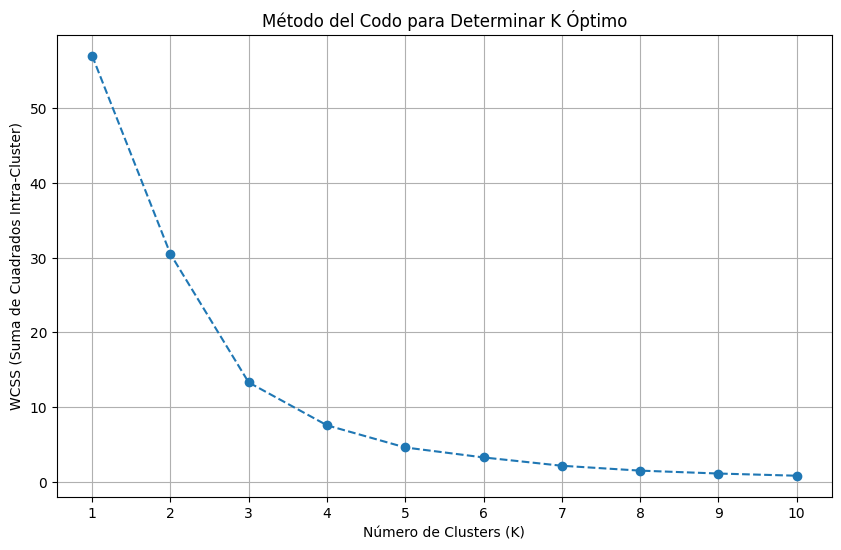

WCSS values for K from 1 to 10: [57.0, 30.474347107898343, 13.287293322872387, 7.554510020344782, 4.588368467137948, 3.254875141825853, 2.1411427820340934, 1.4894489761921785, 1.1009642589604502, 0.8077310960663155]


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Try K values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Determinar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("WCSS values for K from 1 to 10:", wcss)

**Razonamiento**:
Según el gráfico del método del codo y los valores de WCSS, K=3 parece ser una buena opción para el número óptimo de conglomerados, ya que la tasa de disminución de WCSS se ralentiza significativamente después de este punto. El siguiente paso es aplicar la agrupación de K-Means con K=3 a las `scaled_features` y luego asignar las etiquetas del cluster resultante nuevamente al DataFrame original `product_summary`.


In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
product_summary['Cluster'] = kmeans.fit_predict(scaled_features)

print("DataFrame 'product_summary' with assigned clusters:")
print(product_summary.head())

DataFrame 'product_summary' with assigned clusters:
                  Product  total_sales  avg_price_each  \
0            20in Monitor    228889.19          109.99   
1  27in 4K Gaming Monitor   1250697.93          389.99   
2        27in FHD Monitor    575211.56          149.99   
3  34in Ultrawide Monitor   1244847.24          379.99   
4   AA Batteries (4-pack)     54543.36            3.84   

   total_quantity_ordered  Cluster  
0                    2081        0  
1                    3207        0  
2                    3835        0  
3                    3276        0  
4                   14204        2  


**Razonamiento**:
Ahora que los clústeres han sido asignados al DataFrame `product_summary`, el siguiente paso es analizar las características de cada clúster. Esto proporcionará información sobre lo que define a cada grupo de productos en función de sus ventas, precio promedio y cantidad pedida. Calcularé estadísticas descriptivas (media, mediana, desviación estándar) para cada grupo para las características originales (`total_sales`, `avg_price_each` y `total_quantity_ordered`).


In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(scaled_features, product_summary['Cluster'])

print(f"Silhouette Score del modelo: {sil_score:.4f}")

Silhouette Score del modelo: 0.5059


Silhouette Score promedio: 0.5059


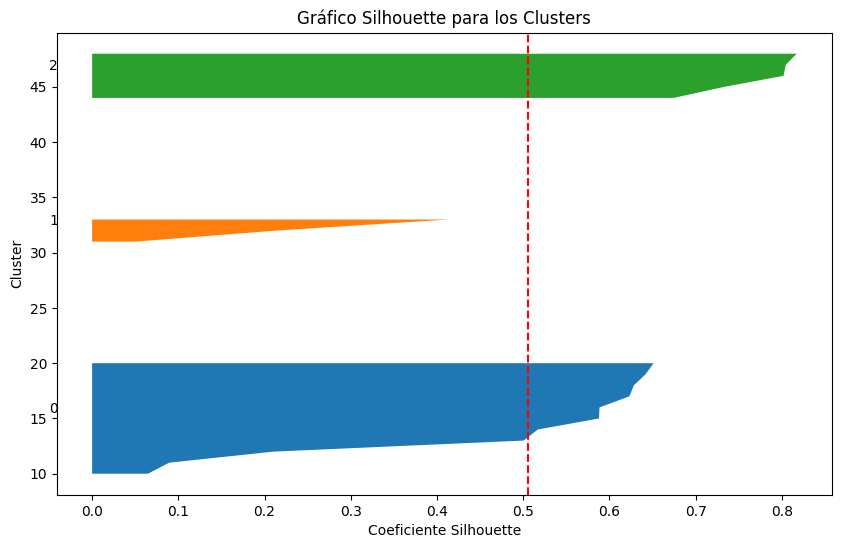

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

# Calcular Silhouette Score promedio
silhouette_avg = silhouette_score(scaled_features, product_summary['Cluster'])
print(f"Silhouette Score promedio: {silhouette_avg:.4f}")

# Calcular valores individuales
sample_silhouette_values = silhouette_samples(scaled_features, product_summary['Cluster'])

y_lower = 10
n_clusters = 3

plt.figure(figsize=(10,6))

for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[product_summary['Cluster'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0,
                      ith_cluster_silhouette_values)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.title("Gráfico Silhouette para los Clusters")
plt.xlabel("Coeficiente Silhouette")
plt.ylabel("Cluster")
plt.show()

##METRICA Silhouette Score
Esta línea importa la función
silhouette_score de la librería slearn.metrics. scikit-learn (o sklearn) es una librería muy popular en Python para Machine Learning, y su módulo metrics contiene diversas funciones para evaluar el rendimiento de los modelos.
sil_score = silhouette_score(scaled_features, product_summary['Cluster']):

Esta es la línea clave donde se calcula el Silhouette Score.
silhouette_score(...): Es la función que calcula la puntuación promedio de silueta para todas las muestras. La puntuación varía de -1 a +1, donde:
+1 indica que las muestras están muy bien agrupadas y muy separadas de otros clusters.
0 indica que las muestras están muy cerca del límite de decisión entre dos clusters adyacentes.
-1 indica que las muestras pueden haber sido asignadas al cluster equivocado.
scaled_features: Es el primer argumento de la función. Representa tus datos escalados (las características total_sales, avg_price_each, total_quantity_ordered después de haber sido transformadas por StandardScaler). La función necesita estos datos para calcular las distancias entre los puntos.
product_summary['Cluster']: Es el segundo argumento. Son las etiquetas de cluster que K-Means asignó a cada producto (0, 1, 2 en este caso). La función utiliza estas etiquetas para saber a qué cluster pertenece cada punto de datos.
El resultado de este cálculo se guarda en la variable sil_score.

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(scaled_features, product_summary['Cluster'])

print(f"Davies-Bouldin Score: {db_score:.4f}")

Davies-Bouldin Score: 0.6390


In [ ]:
print("Características de los Clusters (Media):")
print(product_summary.groupby('Cluster')[['total_sales', 'avg_price_each', 'total_quantity_ordered']].mean())

print("\nCaracterísticas de los Clusters (Mediana):")
print(product_summary.groupby('Cluster')[['total_sales', 'avg_price_each', 'total_quantity_ordered']].median())

print("\nCaracterísticas de los Clusters (Desviación Estándar):")
print(product_summary.groupby('Cluster')[['total_sales', 'avg_price_each', 'total_quantity_ordered']].std())

Características de los Clusters (Media):
          total_sales  avg_price_each  total_quantity_ordered
Cluster                                                      
0        7.753797e+05      343.631818             3140.272727
1        2.903526e+06     1133.330000             2692.666667
2        1.106598e+05        9.144000            12981.600000

Características de los Clusters (Mediana):
         total_sales  avg_price_each  total_quantity_ordered
Cluster                                                     
0          697330.26          379.99                  2890.0
1         2471700.00          999.99                  2417.0
2          126482.51           11.95                 12244.0

Características de los Clusters (Desviación Estándar):
          total_sales  avg_price_each  total_quantity_ordered
Cluster                                                      
0        5.147911e+05      198.662102             2460.514178
1        1.057775e+06      513.161443              740.063

**Razonamiento**:
Para visualizar los grupos y comprender su separación según las características seleccionadas, crearé un diagrama de dispersión. Dadas las tres características utilizadas para la agrupación, un gráfico de pares puede mostrar las relaciones entre todos los pares de características, codificadas por colores por grupo, lo cual es muy eficaz para comprender las características de los grupos.


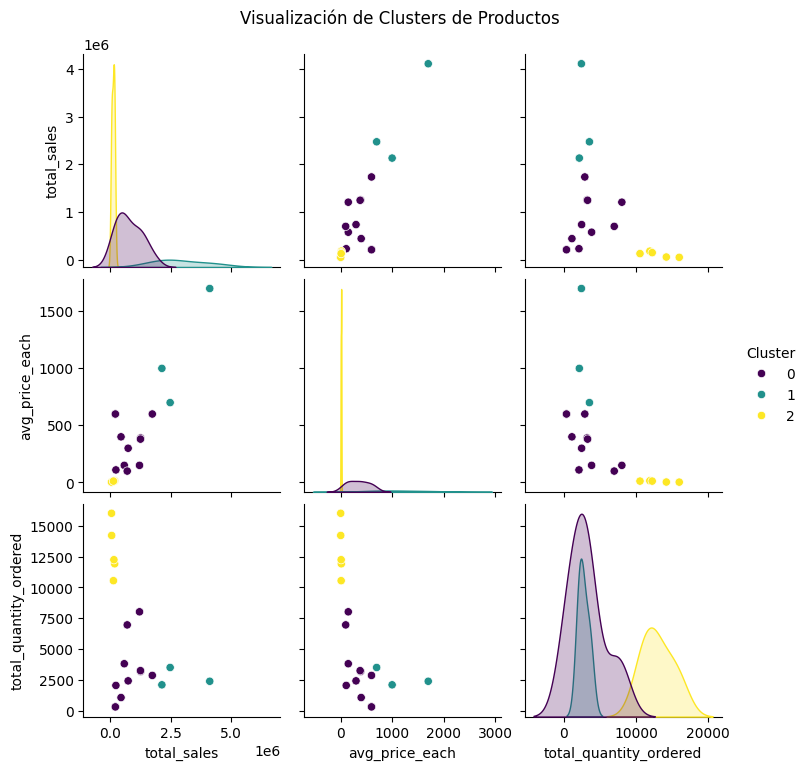

Visualización de los clusters completada. El pair plot muestra la distribución de los productos en cada cluster según sus ventas totales, precio promedio y cantidad total ordenada.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(product_summary, vars=['total_sales', 'avg_price_each', 'total_quantity_ordered'], hue='Cluster', palette='viridis')
plt.suptitle('Visualización de Clusters de Productos', y=1.02)
plt.show()

print("Visualización de los clusters completada. El pair plot muestra la distribución de los productos en cada cluster según sus ventas totales, precio promedio y cantidad total ordenada.")

## Finalizar Tarea

### Subtask:
Resumir los hallazgos de la segmentación K-Means, describiendo los diferentes perfiles de productos identificados y sus implicaciones para el negocio.


## Resumen:

### Preguntas y respuestas
La segmentación de K-Means identificó tres perfiles de productos distintos con las siguientes características e implicaciones comerciales:

* **Grupo 0 (desempeño moderado):** Este grupo consta de productos con ventas moderadamente altas, precios promedio moderados y cantidades moderadas de pedidos. Estos productos representan el segmento de rendimiento promedio.
    * **Implicaciones:** Estos productos podrían orientarse a estrategias de venta adicional, venta cruzada o agrupación para aumentar su valor. El análisis de las tendencias del mercado de estos productos podría revelar oportunidades de ajustes de precios o actividades promocionales para mejorar su desempeño.

* **Grupo 1 (Productos de alto valor/premium):** Este grupo se caracteriza por productos con ventas totales muy altas y precios promedio muy altos, aunque las cantidades totales pedidas son relativamente menores en comparación con otros grupos. Es probable que se trate de artículos premium o de alto valor.
    * **Implicaciones:** Estos productos son cruciales para los ingresos. Los esfuerzos de marketing deben centrarse en resaltar su calidad, exclusividad y dirigirse a clientes adinerados. Las estrategias podrían incluir programas de fidelización, ofertas personalizadas y mantenimiento de una imagen de marca sólida.


* **Grupo 2 (Productos de alto volumen/bajo margen):** Este grupo incluye productos con ventas totales bajas, precios promedio muy bajos y cantidades totales pedidas muy altas. Este perfil sugiere fuertemente productos que son artículos de gran volumen y de bajo margen.
    * **Implicaciones:** Para estos productos, la atención debe centrarse en la eficiencia operativa, optimizar los costos de la cadena de suministro y, potencialmente, utilizarlos como líderes en pérdidas o artículos promocionales para atraer clientes e impulsar el tráfico general en la tienda. La gestión del inventario es clave para evitar el exceso de existencias y al mismo tiempo satisfacer la alta demanda.

### Hallazgos clave del análisis de datos
* Las columnas `total_sales`, `avg_price_each` y `total_quantity_ordered` del marco de datos `product_summary` se escalaron exitosamente usando `StandardScaler` para la agrupación.
* Se determinó que el número óptimo de grupos, K, era 3 utilizando el método del codo. Esto fue evidente en el gráfico donde la disminución en WCSS (suma de cuadrados dentro del grupo) disminuyó significativamente después de K = 3. Por ejemplo, el WCSS disminuyó de 57,0 en K=1 a 13,25 en K=3.
* La agrupación de K-Means se aplicó con 3 agrupaciones y las etiquetas de agrupación resultantes se asignaron a una nueva columna 'Clúster' en el marco de datos `product_summary`.
* El análisis de conglomerados reveló distintos perfiles de productos:
    * **Clúster 0** consta de productos con ventas, precios y cantidades promedio moderados.
    * **Grupo 1** contiene productos con ventas muy altas y precios promedio altos, pero cantidades relativamente más bajas, lo que indica artículos premium.
    * **El grupo 2** agrupa productos con bajas ventas y precios promedio muy bajos pero cantidades muy altas, lo que sugiere productos de alto volumen y bajo margen.
* Un gráfico de pares visualizó con éxito la separación y distribución de productos en los tres grupos en función de sus ventas, precio promedio y métricas de cantidad.

### Ideas o próximos pasos
* Desarrollar estrategias de marketing y ventas personalizadas para cada grupo de productos para maximizar la rentabilidad y la satisfacción del cliente, aprovechando las distintas características identificadas.
* Realizar más investigaciones sobre los productos específicos dentro de cada grupo para comprender los impulsores subyacentes del mercado, la demografía de los clientes y el panorama competitivo, que pueden informar el desarrollo de productos y las decisiones de precios.
